In [1]:
!pip install tensorflow librosa soundfile matplotlib numpy
!git clone https://github.com/breizhn/DTLN.git


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Cloning into 'DTLN'...


In [11]:
import os
import subprocess
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display

plt.rcParams["figure.figsize"] = (10, 3)

os.makedirs("outputs", exist_ok=True)


In [13]:
if not os.path.isdir("DTLN"):
    subprocess.run(["git", "clone", "https://github.com/breizhn/DTLN.git"], check=True)

import sys
sys.path.insert(0, "DTLN")

PRETRAINED_WEIGHTS = os.path.join("DTLN", "pretrained_model", "model.h5")
print("Pretrained weights present:", os.path.exists(PRETRAINED_WEIGHTS))


Pretrained weights present: True


Dataset Loading: Clean Speech + Synthetic Noisy Version

We load a short clean speech clip and synthetically mix in white noise at a chosen SNR to create a
noisy/clean pair for evaluation (DTLN expects 16 kHz mono input).


In [16]:
TARGET_SR = 16000

clean_path = librosa.example('libri1')
y_clean, sr = librosa.load(clean_path, sr=TARGET_SR, mono=True)
y_clean = y_clean / (np.max(np.abs(y_clean)) + 1e-8)

print(f"Clean speech duration: {len(y_clean)/TARGET_SR:.2f} s @ {TARGET_SR} Hz")
display(Audio(y_clean, rate=TARGET_SR))


D:\Conda\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
D:\Conda\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


Clean speech duration: 14.84 s @ 16000 Hz


In [17]:
def add_noise(signal, snr_db=5, seed=0):
    rng = np.random.default_rng(seed)
    noise = rng.normal(0, 1, size=signal.shape)
    sig_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2)
    target_noise_power = sig_power / (10 ** (snr_db / 10))
    noise = noise * np.sqrt(target_noise_power / (noise_power + 1e-12))
    noisy = signal + noise
    peak = np.max(np.abs(noisy))
    return noisy / peak if peak > 1 else noisy

y_noisy = add_noise(y_clean, snr_db=5)

sf.write("outputs/noisy.wav", y_noisy, TARGET_SR)
print("Saved: outputs/noisy.wav")
display(Audio(y_noisy, rate=TARGET_SR))


Saved: outputs/noisy.wav


Load the Pretrained DTLN Model (Inference Only)

We use DTLN's own model-building class so the STFT framing / two-stage LSTM masking pipeline exactly
matches how the weights were trained. No layers are retrained — `load_weights` only.


In [21]:
!pip install wavinfo

   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   -- ----------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from DTLN_model import DTLN_model

dtln = DTLN_model()
dtln.build_DTLN_model(norm_stft=False)
dtln.model.load_weights(PRETRAINED_WEIGHTS)

print("DTLN pretrained model loaded (inference only).")
dtln.model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ [(None, None, 257),       │               0 │ input_layer[0][0]          │
│                               │ (None, None, 257)]        │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, None, 128)         │         197,632 │ lambda[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, None, 128)         │               0 │ lstm[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, None, 128)         │         131,584 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, None, 257)         │          33,153 │ lstm_1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, None, 257)         │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, None, 257)         │               0 │ lambda[0][0],              │
│                               │                           │                 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_1 (Lambda)             │ (None, None, 512)         │               0 │ multiply[0][0],            │
│                               │                           │                 │ lambda[0][1]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, None, 256)         │         131,072 │ lambda_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ instant_layer_normalization   │ (None, None, 256)         │             512 │ conv1d[0][0]               │
│ (InstantLayerNormalization)   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_2 (LSTM)                 │ (None, None, 128)         │         197,120 │ instant_layer_normalizati… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, None, 128)         │               0 │ lstm_2[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_3 (LSTM)                 │ (None, None, 128)         │         131,584 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, None, 256)         │          33,024 │ lstm_3[0][0]               │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 986,753 (3.76 MB)

 Trainable params: 986,753 (3.76 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ [(None, None, 257),       │               0 │ input_layer[0][0]          │
│                               │ (None, None, 257)]        │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, None, 128)         │         197,632 │ lambda[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, None, 128)         │               0 │ lstm[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, None, 128)         │         131,584 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, None, 257)         │          33,153 │ lstm_1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, None, 257)         │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, None, 257)         │               0 │ lambda[0][0],              │
│                               │                           │                 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_1 (Lambda)             │ (None, None, 512)         │               0 │ multiply[0][0],            │
│                               │                           │                 │ lambda[0][1]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, None, 256)         │         131,072 │ lambda_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ instant_layer_normalization   │ (None, None, 256)         │             512 │ conv1d[0][0]               │
│ (InstantLayerNormalization)   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_2 (LSTM)                 │ (None, None, 128)         │         197,120 │ instant_layer_normalizati… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, None, 128)         │               0 │ lstm_2[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_3 (LSTM)                 │ (None, None, 128)         │         131,584 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, None, 256)         │          33,024 │ lstm_3[0][0]               │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 986,753 (3.76 MB)

 Trainable params: 986,753 (3.76 MB)

 Non-trainable params: 0 (0.00 B)

Run Inference to Denoise the Speech

DTLN processes audio directly in the time domain via its combined Keras model
(handles STFT framing / masking / overlap-add internally). We feed the noisy waveform in and get the
denoised waveform out.


In [25]:
def denoise_with_dtln(model, audio, sr=16000, block_len=512, block_shift=128):
    '''Run the pretrained DTLN model over a full waveform using the same
    block-processing approach as the repo's real-time example.'''
    audio = audio.astype(np.float32)

    pad = block_len - (len(audio) % block_shift) if len(audio) % block_shift else 0
    audio_padded = np.concatenate([audio, np.zeros(pad, dtype=np.float32)])

    out_buffer = np.zeros(len(audio_padded) + block_len, dtype=np.float32)
    in_buffer = np.zeros(block_len, dtype=np.float32)

    num_blocks = (len(audio_padded) - block_len) // block_shift + 1
    for i in range(num_blocks):
        start = i * block_shift
        in_buffer[:-block_shift] = in_buffer[block_shift:]
        in_buffer[-block_shift:] = audio_padded[start:start + block_shift]
        pred = model.predict(in_buffer.reshape(1, -1), verbose=0)
        out_buffer[start:start + block_len] += pred.flatten()

    denoised = out_buffer[:len(audio)]
    return denoised

y_denoised = denoise_with_dtln(dtln.model, y_noisy, sr=TARGET_SR)

peak = np.max(np.abs(y_denoised))
if peak > 0:
    y_denoised = y_denoised / peak

sf.write("outputs/denoised.wav", y_denoised, TARGET_SR)
print("Saved: outputs/denoised.wav")
display(Audio(y_denoised, rate=TARGET_SR))


Saved: outputs/denoised.wav


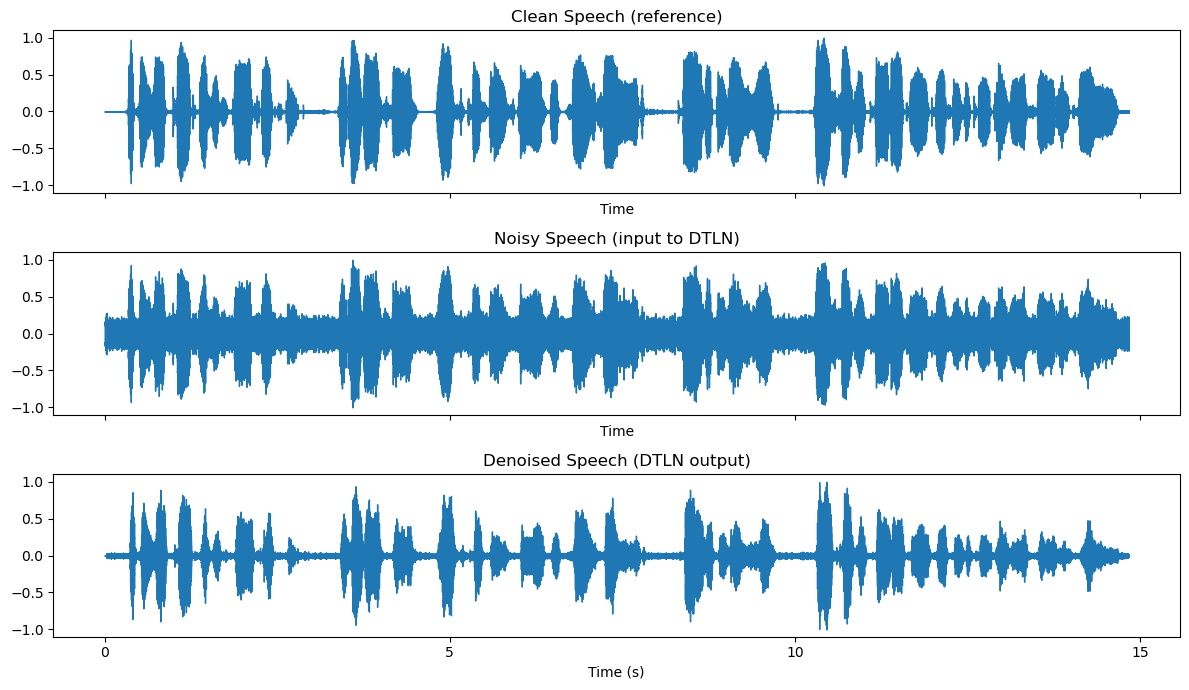

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

librosa.display.waveshow(y_clean, sr=TARGET_SR, ax=axes[0])
axes[0].set_title("Clean Speech (reference)")

librosa.display.waveshow(y_noisy, sr=TARGET_SR, ax=axes[1])
axes[1].set_title("Noisy Speech (input to DTLN)")

librosa.display.waveshow(y_denoised, sr=TARGET_SR, ax=axes[2])
axes[2].set_title("Denoised Speech (DTLN output)")
axes[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()


Visual Comparison: Spectrograms

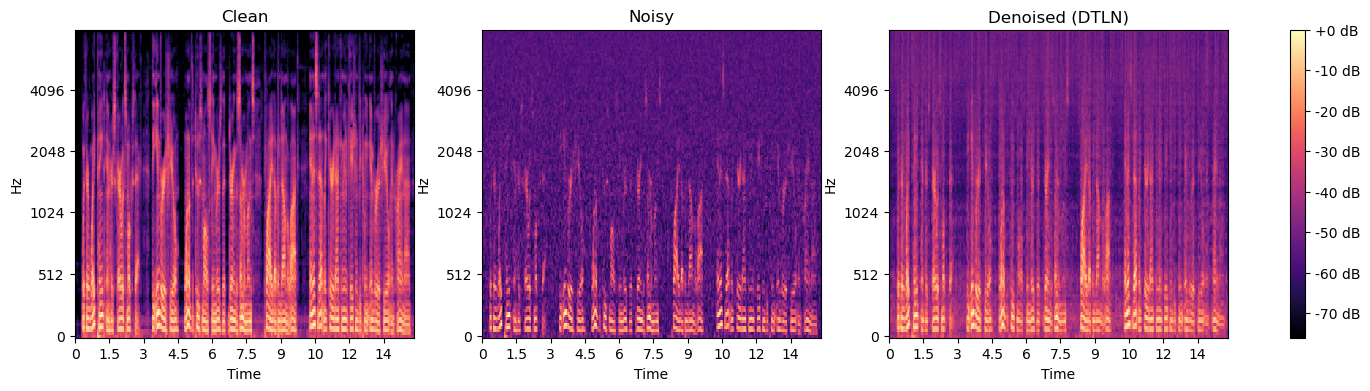

In [30]:
def plot_mel_db(y, sr, ax, title):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(title)
    return img

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
img0 = plot_mel_db(y_clean, TARGET_SR, axes[0], "Clean")
img1 = plot_mel_db(y_noisy, TARGET_SR, axes[1], "Noisy")
img2 = plot_mel_db(y_denoised, TARGET_SR, axes[2], "Denoised (DTLN)")
fig.colorbar(img2, ax=axes, format='%+2.0f dB', fraction=0.02)
plt.show()


Save Denoised Audio Files

Both the noisy input and the denoised output have already been saved to `outputs/`:
- `outputs/noisy.wav`
- `outputs/denoised.wav`


In [32]:
import os
print("Files in outputs/:")
for f in sorted(os.listdir("outputs")):
    print(" -", f, f"({os.path.getsize(os.path.join('outputs', f))/1024:.1f} KB)")


Files in outputs/:
 - denoised.wav (463.8 KB)
 - noisy.wav (463.8 KB)


## Observations

Waveform

Clean speech has clear silence gaps between phrases (flat near-zero segments) and speech bursts rising to ~±1.0.
Noisy speech shows the classic effect of added noise: the "silent" gaps are no longer flat — they're filled with low-level broadband noise, and the whole waveform has a raised noise floor.
Denoised waveform closely resembles the clean waveform again — the noise floor between speech bursts is suppressed and the pauses look flat/clean, similar to the reference. Speech burst shapes are preserved.

Mel-Spectrogram

Clean spectrogram shows sharp, well-defined harmonic bands with dark (low-energy) regions during pauses.
Noisy spectrogram shows energy smeared across almost all frequencies and time frames — the pauses that were dark in "Clean" are now filled with faint noise energy, and the higher frequency bands look muddier.
Denoised spectrogram recovers a lot of that: pause regions turn darker again (noise suppressed) and the sharp harmonic bands are visible again, closer to the clean version — though it's not pixel-identical, some faint residual noise is still visible especially in silent gaps, which is expected of a causal, real-time model like DTLN.
